In [1]:
%run "coli starting run.ipynb"

In [2]:


score_borad = data_create(0,0,0,0)
score_borad = pd.concat([score_borad,data_create(1000,100,100,0)]).reset_index(drop=True)

score_borad['int_score'] = score_borad['score']
score_borad['play_time'] = score_borad.apply(lambda x: 0 if x['type']==1 else x['play_time'],axis=1)
#score_borad['score'] = score_borad['score']-100
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score
0,100,100,0,0,0,0,0,0,6,100
1,100,100,0,0,0,0,0,0,15,100
2,100,100,0,0,0,0,0,0,6,100
3,100,100,0,0,0,0,0,0,0,100
4,100,100,0,0,0,0,0,0,8,100
...,...,...,...,...,...,...,...,...,...,...
995,100,100,0,0,0,0,0,0,19,100
996,100,100,0,0,0,0,0,0,7,100
997,100,100,0,0,0,0,0,0,3,100
998,100,100,0,0,0,0,0,0,2,100


In [3]:
np.random.seed(5)
for i in range(20):
    score_borad = score_borad.sample(frac=1)
    print(i,end="\r", flush=True)
    for id_1 in score_borad.index:
        if score_borad.loc[id_1,'type'] == 2:
            if (i<5):
                score_borad.loc[id_1,'skiped time'] = score_borad.loc[id_1,'skiped time']+1
                continue
        if score_borad.loc[id_1,'att count'] >=score_borad.loc[id_1,'play_time']:
            continue
        pick_list = abs(score_borad['score'] - score_borad.loc[id_1,'score']).drop(id_1).sample(frac=1).sort_values().head(2)
        pick_list = score_borad.loc[pick_list.index]
        id_2 = pick_list[pick_list['true score']==pick_list['true score'].min()].index[0]#np.random.choice(pick_list.index)
        s1,s2 = coli_fight2(score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'],score_borad.loc[id_1,'true score'],score_borad.loc[id_2,'true score'])
        if s1 > score_borad.loc[id_1,'score']:
            score_borad.loc[id_1,'att win'] = score_borad.loc[id_1,'att win']+1
        else:
            score_borad.loc[id_2,'def win'] = score_borad.loc[id_2,'def win']+1
        score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'] = s1,s2
        score_borad.loc[id_1,'att count'],score_borad.loc[id_2,'def count'] = score_borad.loc[id_1,'att count']+1,score_borad.loc[id_2,'def count']+1
score_borad['scorediff'] = score_borad['score'] - score_borad['int_score']
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score,scorediff
552,270,100,0,16,12,10,5,0,16,100,170
676,240,100,0,4,9,2,7,0,4,100,140
160,210,100,0,5,14,4,6,0,5,100,110
181,280,100,0,18,15,13,4,0,18,100,180
865,210,100,0,14,17,6,8,0,14,100,110
...,...,...,...,...,...,...,...,...,...,...,...
682,110,100,0,3,2,1,1,0,3,100,10
574,90,100,0,19,6,7,1,0,19,100,-10
871,230,100,0,12,14,6,7,0,12,100,130
27,270,100,0,11,8,6,6,0,11,100,170


<AxesSubplot:xlabel='score', ylabel='true score'>

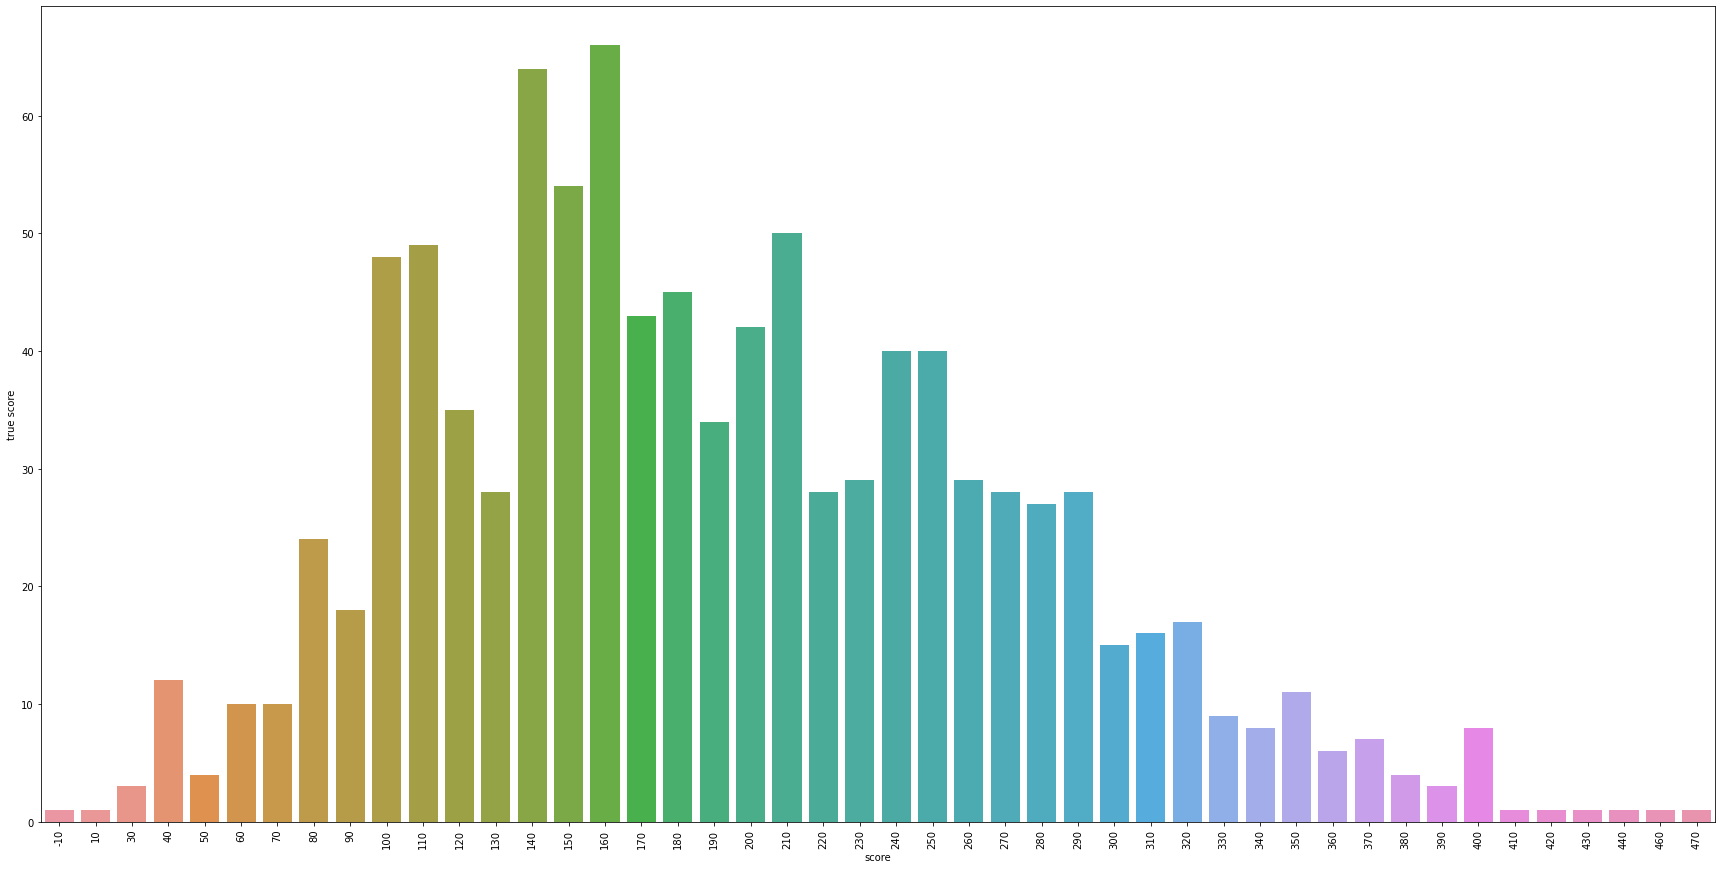

In [4]:
review_df = score_borad.groupby('score')['true score'].count()
fig, ax = plt.subplots(1,figsize=(30, 15),sharey=True)
ax.tick_params(axis='x',labelrotation=90)
sns.barplot(review_df.index,review_df)
#review_df

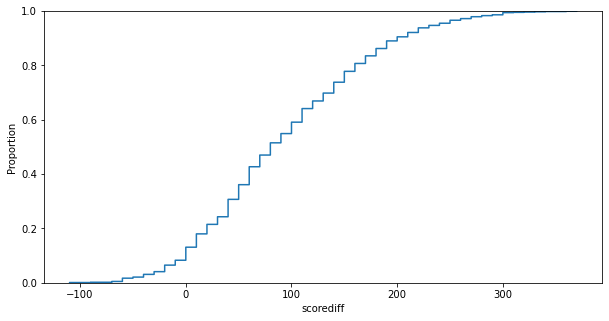

In [5]:


#review_df =score_borad.groupby('scorediff')['true score'].count()/len(score_borad)
kk = score_borad['true score'].unique()
kk.sort()
fig, ax = plt.subplots(1,figsize=(10, 5),sharey=True)
for t_score in kk:
    
    #ax.set_title(str(t_score))
    sns.ecdfplot(data = score_borad[score_borad['true score']==t_score],x="scorediff")
    #fig.show()

In [6]:
score_borad.pivot_table(index ='true score',columns='type' )#.loc[300:399]

,att count,att win,def count,def win,int_score,play_time,score,scorediff,skiped time
type,0,0,0,0,0,0,0,0,0
true score,,,,,,,,,
100,9.29,5.57,9.29,3.73,100,9.29,192.95,92.95,0
